# Sanity Check
## 05 - Epoching

Reading c:\Users\hugoh\OneDrive\01 - Studium\MSc\00 - Module\SpaAohbp\eeg-bala-sharks\sanity_checks\..\data\sub-01_P1_epoch.fif ...


C:\Users\hugoh\AppData\Local\Temp\ipykernel_12084\4122458557.py:10: RuntimeWarning: This filename (../data/sub-01_P1_epoch.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs("../data/sub-01_P1_epoch.fif", preload=True)


    Found the data of interest:
        t =    -200.20 ...    5000.00 ms
        0 CTF compensation matrices available
Not setting metadata
480 matching events found
No baseline correction applied
0 projection items activated
Using matplotlib as 2D backend.


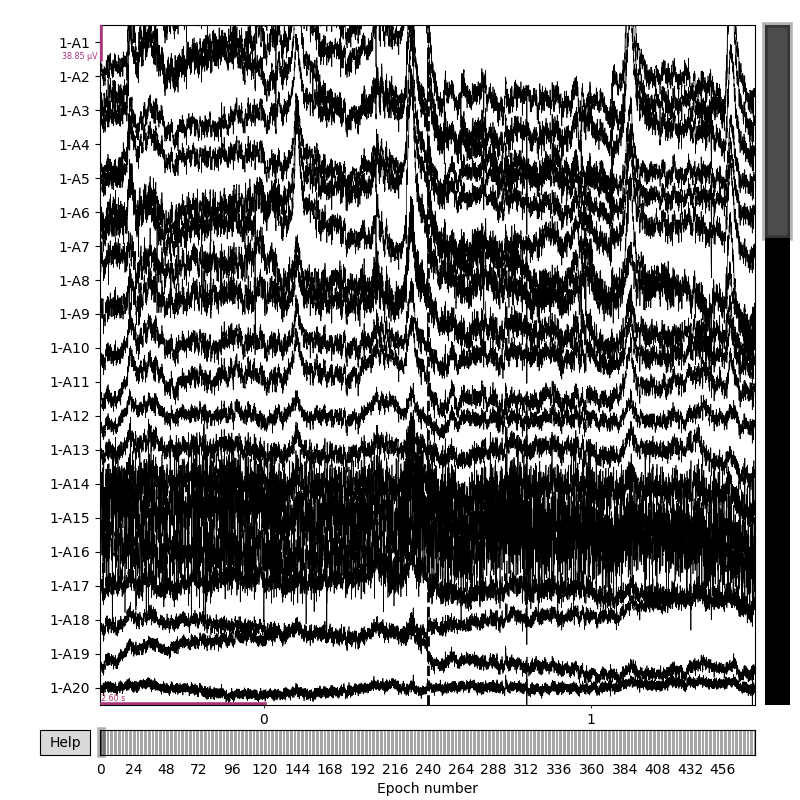

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str((Path.cwd() / '..' / 'eeg_pipeline').resolve()))
%matplotlib ipympl
import config

import mne

# --- Load Epochs ---
epochs = mne.read_epochs("../data/sub-01_P1_epoch.fif", preload=True)

# --- Plot all epochs for overview ---
fig = epochs.plot(scalings='auto', n_epochs=2, title="Epochs P1")

# Add time markers
# Halbtransparente rote Box von 0 bis 1 Sekunde
ax = fig.axes[0] 
for n in range(len(epochs.selection)):
    begin = n*(config.EPOCH_TMAX - config.EPOCH_TMIN) - config.EPOCH_TMIN
    ax.axvspan(begin, begin+2, color='orange', alpha=0.2)
    ax.axvspan(begin+2, begin+4, color='red', alpha=0.2)
    ax.axvspan(begin+4, begin+5, color='purple', alpha=0.2)
ax.axvspan(0, 0, color="orange", alpha=0.2, label='Decision')
ax.axvspan(0, 0, color="red", alpha=0.2, label='Response')
ax.axvspan(0, 0, color="purple", alpha=0.2, label='Feedback')
ax.legend(loc='upper right')